# Merged ATEM Inversion Results Plot

> This is notebook to review the inversion results generated by `tools/main_merged.py`.

## Workflow Overview

- Load merged inversion results (`*_inv_results_atem_full.pik`).
- Conduct binning process using `binning_normal(dx=50)`.
- Calculate active data ratio, misfit per iteration, and regularization metadata
- Interactive plotting function to show depth slice, difference map, L-curve

In [1]:
import json
import os
import sys
from pathlib import Path
from types import SimpleNamespace

import dill
import numpy as np
import pandas as pd
from ipywidgets import VBox, interactive_output, widgets
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from matplotlib.colors import LogNorm
from rich import print
from scipy.spatial import cKDTree as KDTree
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["figure.facecolor"] = "None"

In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"Current Working Directory: {os.getcwd()}")

sys.path.append("tools")
from tools import binning

Current Working Directory: /Volumes/X31/01.Projects/atem

## 1. Load merged inversion restuls and binning configuration

In [3]:
areas = ["NW", "NE", "SE", "SW", "tielines"]
output_prefix = "merged"
dx = 50.0
istart_channel = 3
iend_channel = 25

criteria_rerr = 0.05
criteria_uncertainty = 0.05
bad_line_uncertainty = 0.30
floors_c = 0.05


def rebuild_merged_binned_frames(areas, dx=50.0):
    all_values = []
    all_values_std = []
    all_soundings = []

    times = None
    n_turns = None
    dheader = None
    picker = None

    for area in areas:
        tmp = binning(dx=dx, area=area)
        if times is None:
            times = tmp["times"]
            n_turns = tmp["n_turns"]
            dheader = tmp["dheader"]
            picker = tmp["picker"]

        all_values.extend(tmp["values"])
        all_values_std.extend(tmp["values_std"])
        all_soundings.extend(tmp["soundings"])

    if not all_values:
        raise ValueError("No binned data were reconstructed from the requested areas.")

    df_data_binned = pd.DataFrame(
        data=np.vstack(all_values),
        columns=["Line", "distance"] + picker[1:],
    )
    df_data_std_binned = pd.DataFrame(
        data=np.vstack(all_values_std),
        columns=["bheight"] + dheader,
    )

    for col in df_data_binned.columns:
        if col == "Line":
            df_data_binned[col] = df_data_binned[col].astype(str)
        else:
            df_data_binned[col] = pd.to_numeric(df_data_binned[col], errors="coerce")

    for col in df_data_std_binned.columns:
        df_data_std_binned[col] = pd.to_numeric(
            df_data_std_binned[col], errors="coerce"
        )

    return {
        "times": np.asarray(times, dtype=float),
        "soundings": [int(val) for val in all_soundings],
        "n_turns": float(n_turns),
        "dheader": list(dheader),
        "picker": list(picker),
        "df_data_binned": df_data_binned,
        "df_data_std_binned": df_data_std_binned,
    }

In [4]:
merged_data = rebuild_merged_binned_frames(areas=areas, dx=dx)
times = merged_data["times"]
soundings = merged_data["soundings"]
n_turns = merged_data["n_turns"]
dheader = merged_data["dheader"]
picker = merged_data["picker"]
df_data_binned = merged_data["df_data_binned"]
df_data_std_binned = merged_data["df_data_std_binned"]

In [5]:
# Smooth inversion
atem_data_dir:str = Path(
    "outputs/merged_inversion_results/merged_iteration_14_resistivity_wide-1.csv"
)
atem_df = pd.read_csv(atem_data_dir)
rho_cols = [col for col in atem_df.columns if col.startswith("rho_") and col.endswith("m")]
smooth_inversion = atem_df[rho_cols].values.astype(float)
print(smooth_inversion.shape)

(561475, 22)

In [6]:
result_path = Path("./outputs/sharp/sharp_inv_results_atem_full.pik")
# result_path = Path("./outputs/sharp/sharp_inv_m0_10.pik")

with result_path.open("rb") as f:
    outDict1 = dill.load(f)

In [7]:
iter_keys = sorted(outDict1.keys())
iterations = len(iter_keys)
first_key = iter_keys[0]

print(f"Areas: {areas}")
print(f"Iterations: {iterations}")
print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Per-line sounding counts: {len(soundings):,} lines")
print(f"Stored keys at iteration {first_key}: {list(outDict1[first_key].keys())}")
print(f"m shape: {np.asarray(outDict1[first_key]['m']).shape}")
print(f"dpred shape: {np.asarray(outDict1[first_key]['dpred']).shape}")

Areas: ['NW', 'NE', 'SE', 'SW', 'tielines']

Iterations: 30

Binned soundings: 561,475

Per-line sounding counts: 513 lines

Stored keys at iteration 1: ['iter', 'beta', 'phi_d', 'phi_m', 'f', 'm', 'dpred', 'SparseSmallness.irls_threshold',
'SparseSmallness.norm', 'r LaterallyConstrainedSmoothness.irls_threshold', 'r LaterallyConstrainedSmoothness.norm',
'z LaterallyConstrainedSmoothness.irls_threshold', 'z LaterallyConstrainedSmoothness.norm']

m shape: (12352450,)

dpred shape: (12352450,)

In [8]:
soundings_path = Path("./outputs/sharp/sharp_soundings.json")
if soundings_path.exists():
    with soundings_path.open("r") as f:
        saved_soundings = [int(val) for val in json.load(f)]
    print(f"Saved soundings match reconstructed order: {saved_soundings == soundings}")
else:
    print(
        "No saved merged soundings JSON was found; using reconstructed ordering only."
    )

Saved soundings match reconstructed order: True

## 2. Uncertainty mask, Interpolated map for depth slice

In [9]:
data_ = df_data_binned[dheader].values.astype(float)
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
data_rerr = (
    df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)
).astype(float)
cut_off = (data_rerr > criteria_rerr) * (channel_id >= 0)

floors = 5e-9 / (df_data_binned["TranPeak"].values * n_turns) * floors_c
dobs = df_data_binned[dheader].values.flatten().astype(float)
std = df_data_std_binned[dheader].values.flatten().astype(float)
dobs_std = np.abs(dobs) * criteria_uncertainty
dobs_std[std > dobs_std] = std[std > dobs_std]
dobs_std[cut_off.flatten()] = np.inf
dobs_std += np.repeat(floors, iend_channel - istart_channel)

active_data_count = int(dobs.shape[0] - cut_off.sum())
print(
    f"Active data percentage = {active_data_count:,}/{len(dobs):,} = {active_data_count / len(dobs) * 100:,.1f}%"
)

topography = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values.astype(float)
source_heights = df_data_binned["bheight"].values.astype(float)
thickness = get_vertical_discretization(21, 2, 1.17)
hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

input_data_dict = {
    "topography": topography,
    "source_heights": source_heights,
    "thickness": thickness,
    "times": times,
}
inp = SimpleNamespace(**input_data_dict)

line_no = list(df_data_binned["Line"].astype(str).unique())
line_name_values = [str(val) for val in line_no]
n_sounding = len(df_data_binned)
n_layer = len(hz)
n_time = len(times)

model_size = np.asarray(outDict1[first_key]["m"], dtype=float).size
expected_model_size = n_sounding * n_layer
if model_size != expected_model_size:
    raise ValueError(f"Model size mismatch: {model_size} != {expected_model_size}")

observed_matrix = np.asarray(dobs, dtype=float).reshape((-1, n_time))
phi_d = np.array([outDict1[i]["phi_d"] for i in iter_keys], dtype=float)
phi_m = np.array([outDict1[i]["phi_m"] for i in iter_keys], dtype=float)
no_of_data_points = active_data_count
chi_squared = phi_d / no_of_data_points


def get_iteration_summary(outDict, i_iteration):
    iteration_dict = outDict[i_iteration]
    m_iter = np.asarray(iteration_dict["m"], dtype=float)
    dpred_iter = np.asarray(iteration_dict["dpred"], dtype=float).reshape((-1, n_time))
    rho_layers = (1.0 / np.exp(m_iter)).reshape((n_sounding, n_layer))
    return {
        "m": m_iter,
        "dpred": dpred_iter,
        "rho_layers": rho_layers,
        "phi_d": float(iteration_dict["phi_d"]),
        "phi_m": float(iteration_dict["phi_m"]),
    }


line_slices = {}
distance_by_line = {}
offset = 0
for line_name, count in zip(line_name_values, soundings):
    next_offset = offset + int(count)
    line_slice = slice(offset, next_offset)
    line_slices[str(line_name)] = line_slice
    distance_by_line[str(line_name)] = pd.to_numeric(
        df_data_binned.iloc[line_slice]["distance"],
        errors="coerce",
    ).to_numpy(dtype=float)
    offset = next_offset

if offset != n_sounding:
    raise ValueError(f"Sounding count mismatch: {offset} != {n_sounding}")

map_dx = 100.0
map_dy = 100.0
x_pad = 1000.0
y_pad = 1000.0
k_nearest_points = 100
max_distance = 1000.0
idw_power = 0.0

xy_model = inp.topography[:, :2]
xmin = np.nanmin(xy_model[:, 0]) - x_pad
xmax = np.nanmax(xy_model[:, 0]) + x_pad
ymin = np.nanmin(xy_model[:, 1]) - y_pad
ymax = np.nanmax(xy_model[:, 1]) + y_pad

nx = int(np.floor((xmax - xmin) / map_dx)) + 1
ny = int(np.floor((ymax - ymin) / map_dy)) + 1
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

map_tree = KDTree(xy_model)
k_idw = min(int(k_nearest_points), len(xy_model))
distances_idw, indices_idw = map_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()], k=k_idw
)
if k_idw == 1:
    distances_idw = distances_idw[:, None]
    indices_idw = indices_idw[:, None]

idw_epsilon = min(map_dx, map_dy)
idw_weights = 1.0 / ((distances_idw + idw_epsilon) ** idw_power)
nearest_distance, _ = map_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance


def interpolate_to_map(values):
    values = np.asarray(values, dtype=float)
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(
        idw_weights, axis=1
    )
    values_grid[mask_outside_data] = np.nan
    return values_grid.reshape(X_map.shape)


print(f"n_sounding={n_sounding:,}, n_layer={n_layer}, n_time={n_time}")
print(f"Map grid: {X_map.shape} | k_idw={k_idw}")
print(f"chi-squared normalization uses active data count: {no_of_data_points:,}")

Active data percentage = 10,717,706/12,352,450 = 86.8%

>> Depth from the surface to the base of the bottom layer is 306.3m


n_sounding=561,475, n_layer=22, n_time=22

Map grid: (2054, 1511) | k_idw=100

chi-squared normalization uses active data count: 10,717,706

## 3. Interactive depth slice 

In [ ]:
def plot_combined_map_and_line(i_iteration, line_name, i_depth, outDict):
    summary = get_iteration_summary(outDict, i_iteration)
    rho_layers = summary["rho_layers"]
    dpred_matrix = summary["dpred"]

    values_grid = interpolate_to_map(rho_layers[:, i_depth])
    line_slice = line_slices[str(line_name)]
    selected_line = df_data_binned.iloc[line_slice].copy()
    if selected_line.empty:
        raise ValueError(f"No data found for line {line_name}")

    distances = distance_by_line[str(line_name)]
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    out = ax1.pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    # ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="white",
        linewidth=2.0,
    )
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="black",
        linewidth=0.8,
    )
    ax1.scatter(
        selected_line["x_wgs84"].iloc[0],
        selected_line["y_wgs84"].iloc[0],
        s=30,
        color="white",
        edgecolor="black",
        zorder=5,
    )
    cb = plt.colorbar(out, ax=ax1, orientation="vertical")
    cb.set_label("Resistivity (ohm-m)")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    ax1.set_aspect(1)
    ax1.set_title(
        f"Iteration {i_iteration}, Line {line_name}, Depth {depth_centers[i_depth]:.1f} m"
    )
    ax1.grid(True, alpha=0.15)

    dpred_line = -np.asarray(dpred_matrix[line_slice, :], dtype=float)[sort_idx, :]
    dobs_line = -np.asarray(observed_matrix[line_slice, :], dtype=float)[sort_idx, :]
    for i_time in range(n_time):
        ax2.plot(
            distances_sorted,
            dpred_line[:, i_time],
            "-",
            linewidth=1.0,
            alpha=0.7,
            label=f"T{i_time}" if i_time < 6 else None,
        )
        ax2.plot(
            distances_sorted,
            dobs_line[:, i_time],
            "k--",
            linewidth=0.8,
            alpha=0.35,
        )

    ax2.set_yscale("log")
    ax2.set_xlabel("Distance along line (m)")
    ax2.set_ylabel("|dB/dt| (V/A/m²)")
    ax2.grid(False)
    ax2.set_title(f"Iteration {i_iteration}, Line {line_name}")
    ax2.legend(ncol=2, fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


iter_depth_slider = widgets.IntSlider(
    min=min(iter_keys),
    max=max(iter_keys),
    step=1,
    value=min(iter_keys),
    description="Iteration:",
    continuous_update=False,
)
line_slider = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
)
depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

combined_output = interactive_output(
    plot_combined_map_and_line,
    {
        "i_iteration": iter_depth_slider,
        "line_name": line_slider,
        "i_depth": depth_slider,
        "outDict": widgets.fixed(outDict1)
    },
)

VBox([iter_depth_slider, line_slider, depth_slider, combined_output])

## 5. Interactive XZ cross section 

In [11]:
from simpeg.utils import plot_1d_layer_model

In [ ]:
def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def plot_line_xz_section(
    i_iteration,
    line_name,
    outDict,
    n_sounding=0
):
    line_slice = line_slices[str(line_name)]
    summary = get_iteration_summary(outDict, i_iteration)
    rho_layers = summary["rho_layers"]

    line_rho = rho_layers[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho_sorted = np.asarray(line_rho[sort_idx, :], dtype=float)
    n_sounding = int(n_sounding)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    _, ((ax, ax_loc), (smx, __)) = plt.subplots(
        2,
        2,
        figsize=(20, 10),
        gridspec_kw={"width_ratios": [6, 1]},
    )

    section_smooth = smooth_inversion[line_slice, :][sort_idx, :].T
    section = line_rho_sorted.T

    pcm = ax.pcolormesh(
        X_edges,
        Z_edges,
        section,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    cbar = plt.colorbar(
        pcm,
        ax=ax_loc,
        orientation="vertical",
        fraction=0.08,
        location="left",
    )
    cbar.set_label("Resistivity (ohm-m)")

    ax.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Distance along line (m)")
    ax.set_ylabel("Elevation (m)")
    ax.grid(False)
    ax.set_title(f"Zero-norm | Sounding {n_sounding}")

    x_all = pd.to_numeric(df_data_binned["x_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    y_all = pd.to_numeric(df_data_binned["y_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    x_line = x_all[line_slice][sort_idx]
    y_line = y_all[line_slice][sort_idx]

    all_mask = np.isfinite(x_all) & np.isfinite(y_all)
    line_mask = np.isfinite(x_line) & np.isfinite(y_line)

    if np.any(all_mask):
        ax_loc.scatter(
            x_all[all_mask],
            y_all[all_mask],
            s=2,
            c="lightgray",
            edgecolors="none",
            alpha=0.7,
        )

    if np.any(line_mask):
        ax_loc.plot(
            x_line[line_mask],
            y_line[line_mask],
            color="crimson",
            linewidth=1.6,
            zorder=3,
        )
        ax_loc.scatter(
            x_line[line_mask][n_sounding],
            y_line[line_mask][n_sounding],
            s=26,
            c="white",
            edgecolors="black",
            zorder=4,
        )
    else:
        ax_loc.text(
            0.5,
            0.5,
            "No valid XY",
            ha="center",
            va="center",
            transform=ax_loc.transAxes,
        )

    ax_loc.set_aspect(1)
    ax_loc.set_title(f"Locator\nLine {line_name}")
    # ax_loc.set_xlabel("x_wgs84")
    # ax_loc.set_ylabel("y_wgs84")
    ax_loc.grid(False)

    smx.pcolormesh(
        X_edges,
        Z_edges,
        section_smooth,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    smx.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    smx.set_title("Smooth Inversion")

    # __.plot(
    #     section[:, n_sounding],
    #     depth_centers,
    #     label="Zero-norm",
    # )
    # __.plot(
    #     section_smooth[:, n_sounding],
    #     depth_centers,
    #     color="red",
    #     linewidth=1.0,
    #     alpha=0.7,
    #     label="Smooth",
    # )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section[:, n_sounding],
        ax=__,
        scale="log",          
        plot_elevation=False, 
    )
    # print(section[:, n_sounding])
    # print(observed_matrix[line_slice, :][sort_idx, :][n_sounding])
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section_smooth[:, n_sounding],
        ax=__,
        scale="log",          # 비저항 값의 변화 범위가 클 때 log 스케일 지정 ('linear' 또는 'log')
        plot_elevation=False, # True이면 y축이 고도(Elevation), False이면 깊이(Depth)로 표현
        # show_layers=True,     # 각 층의 경계선(수평선) 표시 여부
    )
    # __.invert_yaxis()
    __.set_xlabel("Resistivity (ohm-m)")
    __.set_ylabel("Depth (m)")
    __.set_title(f"Sounding {n_sounding}")
    __.set_xlim(3, 60)
    __.set_xscale("log")
    __.minorticks_on()
    __.grid(True, which="both")
    # __.legend()
    __.legend(["L-0", "Smooth"])

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

sound_slider_xz = widgets.IntSlider(
    min=0,
    max=int(soundings[0]) - 1,
    step=1,
    value=0,
    description="Sounding:",
    continuous_update=False,
)


def update_xz_sounding_slider(change):
    line_index = line_name_values.index(change["new"])
    sound_slider_xz.max = int(soundings[line_index]) - 1
    sound_slider_xz.value = 0


line_slider_xz.observe(update_xz_sounding_slider, names="value")

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration": iter_slider_xz,
        "line_name": line_slider_xz,
        "n_sounding": sound_slider_xz,
        "outDict": widgets.fixed(outDict1),
    },
)

VBox(
    [
        iter_slider_xz,
        line_slider_xz,
        sound_slider_xz,
        xz_output,
    ]
)

In [13]:
def plot_line_xz_section_2(
    i_iteration1,
    line_name,
    outDict,
    i_iteration2=5,
    n_sounding=0
):
    line_slice = line_slices[str(line_name)]
    summary1 = get_iteration_summary(outDict, i_iteration1)
    summary2 = get_iteration_summary(outDict, i_iteration2)
    rho_layers1 = summary1["rho_layers"]
    rho_layers2 = summary2["rho_layers"]

    line_rho1 = rho_layers1[line_slice, :]
    line_rho2 = rho_layers2[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
    line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)
    n_sounding = int(n_sounding)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    _, ((ax, ax_loc), (smx, __)) = plt.subplots(
        2,
        2,
        figsize=(20, 10),
        gridspec_kw={"width_ratios": [6, 1]},
    )

    section1 = line_rho1_sorted.T
    section2 = line_rho2_sorted.T

    pcm = ax.pcolormesh(
        X_edges,
        Z_edges,
        section1,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    cbar = plt.colorbar(
        pcm,
        ax=ax_loc,
        orientation="vertical",
        fraction=0.08,
        location="left",
    )
    cbar.set_label("Resistivity (ohm-m)")

    ax.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Distance along line (m)")
    ax.set_ylabel("Elevation (m)")
    ax.grid(False)
    ax.set_title(f"Zero-norm | Sounding {n_sounding}")

    x_all = pd.to_numeric(df_data_binned["x_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    y_all = pd.to_numeric(df_data_binned["y_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    x_line = x_all[line_slice][sort_idx]
    y_line = y_all[line_slice][sort_idx]

    all_mask = np.isfinite(x_all) & np.isfinite(y_all)
    line_mask = np.isfinite(x_line) & np.isfinite(y_line)

    if np.any(all_mask):
        ax_loc.scatter(
            x_all[all_mask],
            y_all[all_mask],
            s=2,
            c="lightgray",
            edgecolors="none",
            alpha=0.7,
        )

    if np.any(line_mask):
        ax_loc.plot(
            x_line[line_mask],
            y_line[line_mask],
            color="crimson",
            linewidth=1.6,
            zorder=3,
        )
        ax_loc.scatter(
            x_line[line_mask][n_sounding],
            y_line[line_mask][n_sounding],
            s=26,
            c="white",
            edgecolors="black",
            zorder=4,
        )
    else:
        ax_loc.text(
            0.5,
            0.5,
            "No valid XY",
            ha="center",
            va="center",
            transform=ax_loc.transAxes,
        )

    ax_loc.set_aspect(1)
    ax_loc.set_title(f"Locator\nLine {line_name}")
    # ax_loc.set_xlabel("x_wgs84")
    # ax_loc.set_ylabel("y_wgs84")
    ax_loc.grid(False)

    smx.pcolormesh(
        X_edges,
        Z_edges,
        section2,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    smx.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    smx.set_title("Smooth Inversion")

    __.plot(
        section1[:, n_sounding],
        depth_centers,
        label="Zero-norm",
    )
    __.plot(
        section2[:, n_sounding],
        depth_centers,
        color="red",
        linewidth=1.0,
        alpha=0.7,
        label="Smooth",
    )
    __.invert_yaxis()
    __.set_xlabel("Resistivity (ohm-m)")
    __.set_ylabel("Depth (m)")
    __.set_title(f"Sounding {n_sounding}")
    __.set_xlim(5, 60)
    __.set_xscale("log")
    __.grid(True)
    __.legend()

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

sound_slider_xz = widgets.IntSlider(
    min=0,
    max=int(soundings[0]) - 1,
    step=1,
    value=0,
    description="Sounding:",
    continuous_update=False,
)


def update_xz_sounding_slider(change):
    line_index = line_name_values.index(change["new"])
    sound_slider_xz.max = int(soundings[line_index]) - 1
    sound_slider_xz.value = 0


line_slider_xz.observe(update_xz_sounding_slider, names="value")

xz_output = interactive_output(
    plot_line_xz_section_2,
    {
        "i_iteration1": iter_slider_xz,
        "line_name": line_slider_xz,
        "n_sounding": sound_slider_xz,
        "outDict": widgets.fixed(outDict1),
    },
)

VBox(
    [
        iter_slider_xz,
        line_slider_xz,
        sound_slider_xz,
        xz_output,
    ]
)

## 6. Gradient criteria, \(\chi^2\), L-curve

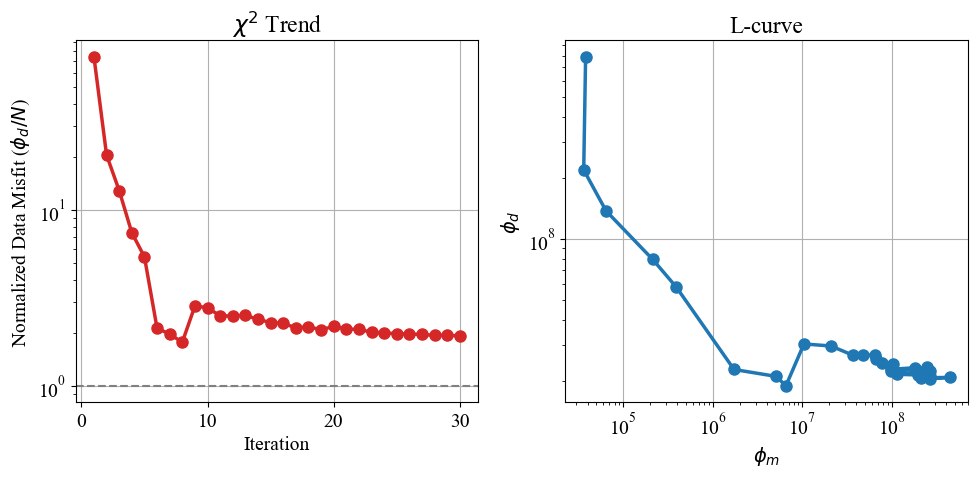

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(
    iter_keys, chi_squared, marker="o", color="tab:red", linewidth=2.5, markersize=8
)
plt.axhline(
    y=1.0, color="gray", linestyle="--", linewidth=1.5, label="Target $\\chi^2$"
)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Normalized Data Misfit ($\\phi_d / N$)")
plt.title("$\\chi^2$ Trend")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(phi_m, phi_d, marker="o", color="tab:blue", linewidth=2.5, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.title("L-curve")
plt.xlabel("$\\phi_m$")
plt.ylabel("$\\phi_d$")
plt.grid()
plt.tight_layout()
plt.show()